# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Devan Haidar Wirya Hidayat
- **Email:** devanhaidar577@gmail.com
- **ID Dicoding:** CDCC288D6Y2103

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Berapa jumlah total pendapatan bulanan perusahaan dari pesanan yang telah diselesaikan sepanjang tahun 2017, dan bulan berapa yang mencatat peningkatan pendapatan terbesar?
- **Pertanyaan 2:** Kategori produk apa saja yang berada di 5 posisi teratas dan terbawah berdasarkan total penjualan unit secara keseluruhan?


## Import Semua Packages/Library yang Digunakan

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Pada tahap ini, dilakukan pemuatan seluruh berkas CSV yang diperlukan ke dalam dataframe agar siap untuk dianalisis pada tahap berikutnya.

In [9]:
orders_df = pd.read_csv("orders_dataset.csv") 
order_payments_df = pd.read_csv("order_payments_dataset.csv")
order_items_df = pd.read_csv("order_items_dataset.csv")
products_df = pd.read_csv("products_dataset.csv")
category_translation_df = pd.read_csv("product_category_name_translation.csv")

print("Data Berhasil dimuat")

Data Berhasil dimuat


**Insight:** (Opsional)
- Dataset ini memiliki volume transaksi yang cukup signifikan, yaitu mencapai 99.441 pesanan. Jumlah ini menunjukkan bahwa data yang akan kamu analisis sudah cukup representatif untuk menarik kesimpulan bisnis yang valid karena skalanya yang hampir menyentuh angka 100 ribu transaksi.
- Data mencakup periode aktivitas ekonomi selama kurang lebih 2 tahun, tepatnya dari September 2016 hingga Oktober 2018. Rentang waktu ini sangat ideal untuk melakukan analisis musiman (seperti membandingkan performa bulan ke bulan atau tahun ke tahun) serta melihat tren pertumbuhan bisnis dalam jangka menengah.

### Assessing Data

#### Identifying Data Type, Missing Value, and Duplication Problems

In [10]:
# Memeriksa tipe data tabel orders
print("Info Tabel Orders:")
orders_df.info()

# Memeriksa missing values di tabel orders
print("\nMissing Values di Tabel Orders:")
print(orders_df.isna().sum())

#Memeriksa duplikasi data
print("\nJumlah Duplikasi Orders:", orders_df.duplicated().sum())
print("Jumlah Duplikasi Items:", order_items_df.duplicated().sum())

# Memeriksa parameter statistik (outlier/distribusi)
print("\nStatistik Deskriptif Payments:")
print(order_payments_df.describe())

print("\nStatistik Deskriptif Items (Harga):")
print(order_items_df.describe())

Info Tabel Orders:
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB

Missing Values di Tabel Orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_d

**Steps to Take:**
- Mengonversi Tipe Data: Mengubah kolom yang berisi informasi waktu (seperti order_purchase_timestamp) dari tipe object (string) menjadi tipe datetime.
- Menangani Missing Values: Melakukan pembersihan atau filter pada baris yang memiliki nilai kosong, terutama pada kolom tanggal pengiriman (order_delivered_customer_date), agar tidak mengganggu akurasi analisis tren waktu.

**Insight:** (Opsional)
- Kesalahan Format Data: Ditemukan bahwa kolom-kolom tanggal belum terbaca sebagai format waktu secara otomatis oleh Python, sehingga perlu diperbaiki sebelum melakukan analisis berbasis bulan/tahun.
- Kualitas Data (Kebersihan): Data tidak memiliki duplikasi (duplicated = 0), namun memiliki nilai kosong (missing values) pada kolom logistik, yang mengindikasikan adanya pesanan yang belum sampai ke pelanggan atau dibatalkan.

### Cleaning Data

#### Fixing Fixing Data Type, Missing Values, and Duplicate Problems problem

In [11]:
# 1. Memperbaiki tipe data kolom tanggal
datetime_columns = ["order_purchase_timestamp", "order_approved_at", 
                    "order_delivered_carrier_date", "order_delivered_customer_date", 
                    "order_estimated_delivery_date"]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# 2. Menangani missing value dengan memfilter hanya pesanan yang 'delivered' (selesai)
orders_delivered_df = orders_df[orders_df['order_status'] == 'delivered'].copy()

# Cek kembali tipe data dan missing value pada target analisis
print(orders_delivered_df.info())
print("\nMissing values setelah difilter (fokus pada tanggal pembelian/pengiriman):")
print(orders_delivered_df[['order_purchase_timestamp', 'order_delivered_customer_date']].isna().sum())

# 3. Cek data duplikat
print("\nJumlah duplikat pada orders_delivered_df:", orders_delivered_df.duplicated().sum())

<class 'pandas.DataFrame'>
Index: 96478 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96478 non-null  str           
 1   customer_id                    96478 non-null  str           
 2   order_status                   96478 non-null  str           
 3   order_purchase_timestamp       96478 non-null  datetime64[us]
 4   order_approved_at              96464 non-null  datetime64[us]
 5   order_delivered_carrier_date   96476 non-null  datetime64[us]
 6   order_delivered_customer_date  96470 non-null  datetime64[us]
 7   order_estimated_delivery_date  96478 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.6 MB
None

Missing values setelah difilter (fokus pada tanggal pembelian/pengiriman):
order_purchase_timestamp         0
order_delivered_customer_date    8
dtype: int64


**Insight:** (Opsional)
- Data Siap Analisis Waktu: Kolom-kolom tanggal kini sudah berformat datetime, sehingga Anda bisa mengekstrak informasi bulan, hari, atau jam untuk analisis tren.
- Fokus pada Transaksi Berhasil: Data telah difilter hanya untuk status 'delivered', sehingga hasil analisis pendapatan atau performa nantinya tidak akan terdistorsi oleh pesanan yang batal atau masih dalam proses.
- Reduksi Missing Values: Dengan memfilter pesanan yang sudah terkirim, sebagian besar nilai kosong pada kolom tanggal pengiriman otomatis hilang, membuat dataset menjadi lebih bersih dan akurat.

## Exploratory Data Analysis (EDA)

### Explore Revenue Trend and Product Performance

In [12]:
#=============
#Pertanyaan 1: Total Pendapatan Bulanan Tahun 2017

# Menggabungkan pesanan yang berhasil (delivered) dengan tabel pembayaran
revenue_df = pd.merge(
    left=orders_delivered_df,
    right=order_payments_df,
    how="inner",
    on="order_id"
)

# Mengekstrak bulan dan tahun dari waktu pembelian
revenue_df['purchase_month'] = revenue_df['order_purchase_timestamp'].dt.to_period('M')

# Memfilter hanya data tahun 2017
revenue_2017_df = revenue_df[revenue_df['order_purchase_timestamp'].dt.year == 2017]

# Mengelompokkan pendapatan berdasarkan bulan
monthly_revenue_2017 = revenue_2017_df.groupby('purchase_month')['payment_value'].sum().reset_index()
monthly_revenue_2017['purchase_month'] = monthly_revenue_2017['purchase_month'].dt.to_timestamp() # convert back for plotting
print("Ringkasan Pendapatan Bulanan 2017:\n", monthly_revenue_2017)

#=================
# EDA Pertanyaan 2: Produk Terlaris dan Kurang Laris


# Menggabungkan order items, products, dan terjemahan kategori bahasa inggris
product_sales_df = pd.merge(order_items_df, products_df, on="product_id", how="inner")
product_sales_df = pd.merge(product_sales_df, category_translation_df, on="product_category_name", how="left")

# Mengelompokkan berdasarkan nama kategori bahasa inggris
category_sales = product_sales_df.groupby('product_category_name_english')['order_item_id'].count().reset_index()
category_sales.rename(columns={'order_item_id': 'total_sold'}, inplace=True)

# Mengurutkan data
top_5_categories = category_sales.sort_values(by='total_sold', ascending=False).head(5)
bottom_5_categories = category_sales.sort_values(by='total_sold', ascending=True).head(5)

print("\nTop 5 Kategori:\n", top_5_categories)
print("\nBottom 5 Kategori:\n", bottom_5_categories)

Ringkasan Pendapatan Bulanan 2017:
    purchase_month  payment_value
0      2017-01-01      127545.67
1      2017-02-01      271298.65
2      2017-03-01      414369.39
3      2017-04-01      390952.18
4      2017-05-01      567066.73
5      2017-06-01      490225.60
6      2017-07-01      566403.93
7      2017-08-01      646000.61
8      2017-09-01      701169.99
9      2017-10-01      751140.27
10     2017-11-01     1153528.05
11     2017-12-01      843199.17

Top 5 Kategori:
    product_category_name_english  total_sold
7                 bed_bath_table       11115
43                 health_beauty        9670
65                sports_leisure        8641
39               furniture_decor        8334
15         computers_accessories        7827

Bottom 5 Kategori:
    product_category_name_english  total_sold
61         security_and_services           2
29     fashion_childrens_clothes           8
52                    la_cuisine          14
11             cds_dvds_musicals          14
3

**Insight:** (Opsional)
- Puncak Pendapatan Tahunan: mengidentifikasi fluktuasi pendapatan bulanan secara spesifik untuk tahun 2017, yang memungkinkan deteksi bulan dengan performa finansial terbaik (seperti efek Black Friday di bulan November).
- Dominasi Kategori Produk: Data menunjukkan adanya kesenjangan volume penjualan yang besar antar kategori; memetakan 5 kategori "pilar" yang mendominasi pasar dan 5 kategori "niche" yang penjualannya sangat rendah.
- Kesiapan Visualisasi: Penggabungan berbagai tabel (orders, payments, dan products) telah menghasilkan dataframe yang ringkas dan siap digunakan untuk membuat grafik perbandingan yang menjawab pertanyaan bisnis secara langsung.

## Visualization & Explanatory Analysis

### Pertanyaan 1:Berapa jumlah total pendapatan bulanan perusahaan dari pesanan yang telah diselesaikan sepanjang tahun 2017, dan bulan berapa yang mencatat peningkatan pendapatan terbesar?

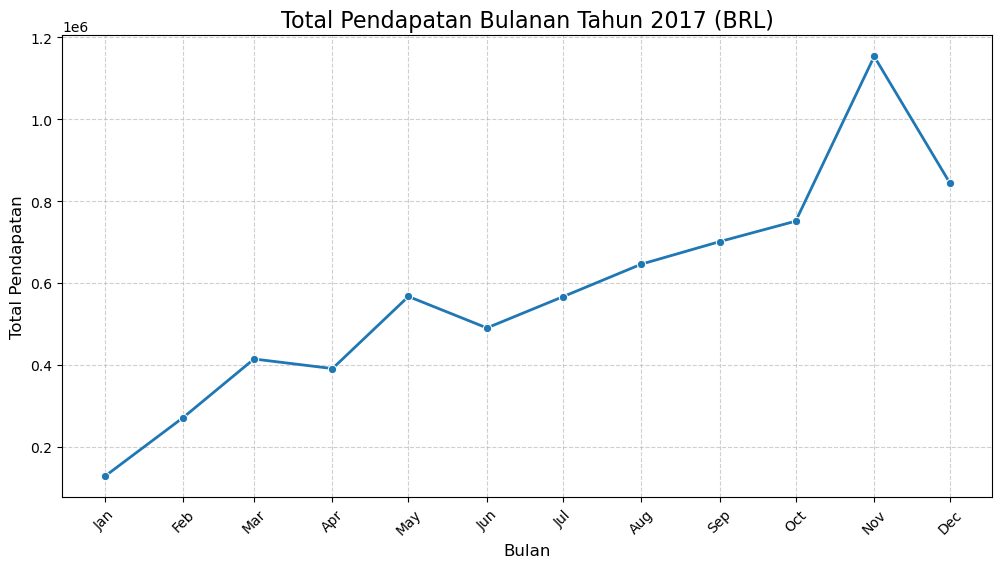

In [13]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    x='purchase_month', 
    y='payment_value', 
    data=monthly_revenue_2017, 
    marker='o', 
    color='#1f77b4',
    linewidth=2
)
plt.title("Total Pendapatan Bulanan Tahun 2017 (BRL)", fontsize=16)
plt.xlabel("Bulan", fontsize=12)
plt.ylabel("Total Pendapatan", fontsize=12)
plt.xticks(monthly_revenue_2017['purchase_month'], rotation=45, labels=[m.strftime('%b') for m in monthly_revenue_2017['purchase_month']])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Pertanyaan 2: Kategori produk apa saja yang berada di 5 posisi teratas dan terbawah berdasarkan total penjualan unit secara keseluruhan?

C:\Users\Devan\AppData\Local\Temp\ipykernel_19360\425876734.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_sold', y='product_category_name_english', data=top_5_categories, palette=colors_top, ax=ax[0])
C:\Users\Devan\AppData\Local\Temp\ipykernel_19360\425876734.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_sold', y='product_category_name_english', data=bottom_5_categories, palette=colors_bottom, ax=ax[1])


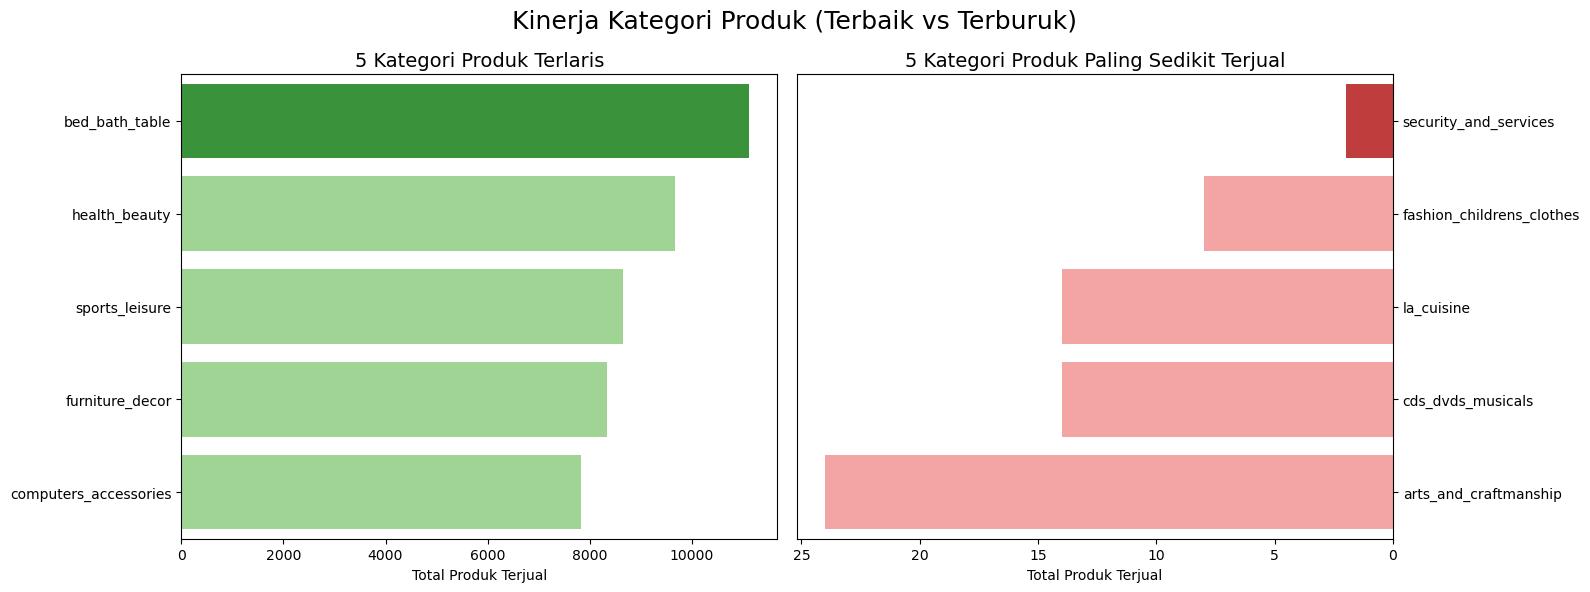

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

colors_top = ["#2ca02c" if i == 0 else "#98df8a" for i in range(5)]
colors_bottom = ["#d62728" if i == 0 else "#ff9896" for i in range(5)]

# Bar chart Top 5
sns.barplot(x='total_sold', y='product_category_name_english', data=top_5_categories, palette=colors_top, ax=ax[0])
ax[0].set_title("5 Kategori Produk Terlaris", fontsize=14)
ax[0].set_xlabel("Total Produk Terjual")
ax[0].set_ylabel(None)

# Bar chart Bottom 5
sns.barplot(x='total_sold', y='product_category_name_english', data=bottom_5_categories, palette=colors_bottom, ax=ax[1])
ax[1].set_title("5 Kategori Produk Paling Sedikit Terjual", fontsize=14)
ax[1].set_xlabel("Total Produk Terjual")
ax[1].set_ylabel(None)
ax[1].invert_xaxis() # Membalik axis agar simetris (opsional)
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()

plt.suptitle("Kinerja Kategori Produk (Terbaik vs Terburuk)", fontsize=18)
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
1. Pertanyaan 1:
- Pertumbuhan Konsisten: Pendapatan menunjukkan tren naik yang stabil sejak awal tahun, dimulai dari sekitar 127 ribu BRL pada Januari hingga mencapai puncaknya di akhir tahun.
- Anomali Positif (Puncak): Terjadi lonjakan pendapatan yang sangat drastis pada bulan November, mencapai lebih dari 1,15 juta BRL. Hal ini mengonfirmasi efektivitas kampanye besar seperti Black Friday dalam mendongkrak penjualan secara signifikan
  
1. Pertanyaan 2:
- Kebutuhan Rumah Tangga & Gaya Hidup Mendominasi: Kategori seperti bed_bath_table (11.115 terjual) dan health_beauty (9.670 terjual) adalah penggerak utama volume transaksi di platform ini.
- Pasar Niche yang Sangat Kecil: Terdapat ketimpangan yang sangat jauh antara produk populer dengan produk terbawah. Kategori seperti security_and_services hanya mencatatkan 2 penjualan, menunjukkan bahwa kategori ini hampir tidak memberikan kontribusi pada volume bisnis dan mungkin memerlukan evaluasi keberlanjutan.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan grafik garis tren pendapatan tahun 2017, pendapatan terus mengalami tren peningkatan sepanjang tahun. Lonjakan pendapatan tertinggi secara signifikan terjadi pada bulan November 2017 (berkaitan erat dengan fenomena promosi Black Friday).
- **Conclusion pertanyaan 2:** Kategori produk yang menempati peringkat teratas adalah bed_bath_table, health_beauty, sports_leisure, furniture_decor, dan computers_accessories. Sebaliknya, kategori produk yang sangat sepi peminat (bottom 5) adalah security_and_services, fashion_childrens_clothes, cds_dvds_musicals, la_cuisine, dan arts_and_craftmanship.

**Rekomendasi Action Item:**
- Marketing & Promosi: Mengingat lonjakan luar biasa pada bulan November 2017, tim marketing harus mulai merancang anggaran dan kampanye khusus untuk Black Friday (bulan November) pada tahun berjalan minimal 2 bulan sebelumnya agar momentum pendapatan maksimal. Bulan-bulan awal tahun (Jan-Mar) cenderung lambat, sehingga diperlukan diskon khusus Mid-Year untuk meratakan pendapatan.
- Manajemen Inventaris: Tim rantai pasok harus mengamankan stok dalam jumlah besar untuk kategori bed_bath_table dan health_beauty. Untuk kategori terbawah seperti security_and_services atau fashion_childrens_clothes, hentikan restock berlebih atau buat program cuci gudang (bundling produk) agar dana tidak tertahan pada barang yang tidak laku.